# Feature Importance Analysis for TFT Models

This notebook analyzes feature importances extracted from Temporal Fusion Transformer (TFT) models.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from pathlib import Path
import yaml
from scipy.stats import wilcoxon, mannwhitneyu

# Set publication-ready style
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['font.family'] = 'sans-serif'

# Color palette for consistent design
COLORS = {
    'static': '#2E86AB',   # Blue
    'past': '#A23B72',     # Purple
    'future': '#F18F01'    # Orange
}

with open('../configs/config_wind_50.yaml', 'r') as f:
    config_50 = yaml.safe_load(f)

with open('../configs/config_wind_100.yaml', 'r') as f:
    config_100 = yaml.safe_load(f)

parks_50 = config_50['data']['files']
parks_100 = config_100['data']['files']


## 1. Get Wind Park Parameters

In [3]:
df_all = pd.read_csv('results/feature_importances_all.csv', dtype={'station_id': str})

df_global = pd.read_csv('results/feature_importances_global.csv')

df_nostatic = pd.read_csv('results/feature_importances_wind_50_nostatic.csv', dtype={'station_id': str})

df_wind50 = pd.read_csv('results/feature_importances_wind_50.csv', dtype={'station_id': str})

df_wind100 = pd.read_csv('results/feature_importances_wind_100.csv', dtype={'station_id': str})

df_params = pd.read_csv('../data/station_turbine_assignments.csv', dtype={'station_id': str})

station_ids = df_all['station_id'].unique()
df_params = df_params[df_params['station_id'].isin(station_ids)]

In [4]:
def merge_full_importance(params: pd.DataFrame, importances: pd.DataFrame, static: bool = False) -> pd.DataFrame:
    df_params = params.copy()
    df_importances = importances.copy()
    df_past = df_importances[df_importances['feature_type'] == 'past'].copy()
    if static:
        df_static = df_importances[df_importances['feature_type'] == 'static'].copy()
        params_importance = df_params.merge(df_static, on='station_id', how='left')
    else:
        params_importance = df_params.copy()
    # Filter for future features and find the most important one per station
    df_future = df_importances[df_importances['feature_type'] == 'future'].copy()
    # Merge with df_params
    params_importance = params_importance.merge(df_future, on='station_id', how='left')
    params_importance = params_importance.merge(df_past, on='station_id', how='left')
    return params_importance

In [38]:
std_group =df_wind100.groupby(['station_id', 'feature_type']).agg({'avg_weight': 'std'}).reset_index()

group_altitude = std_group.merge(df_params[['station_id', 'altitude']], on='station_id')
merge_altitude = df_wind100.merge(df_params[['station_id', 'altitude']], on='station_id')
merge_altitude = merge_altitude.loc[merge_altitude['feature_type'] == 'future']

future = group_altitude.loc[group_altitude['feature_type'] == 'future'][['avg_weight', 'altitude']]
past = group_altitude.loc[group_altitude['feature_type'] == 'past'][['avg_weight', 'altitude']]
static = group_altitude.loc[group_altitude['feature_type'] == 'static'][['avg_weight', 'altitude']]

In [47]:
bins = [1, 42.75, 156.5, 386.25, 900]

labels = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]

merge_altitude['altitude_qcut'], bins = pd.qcut(merge_altitude['altitude'], q=4, labels=labels, retbins=True)

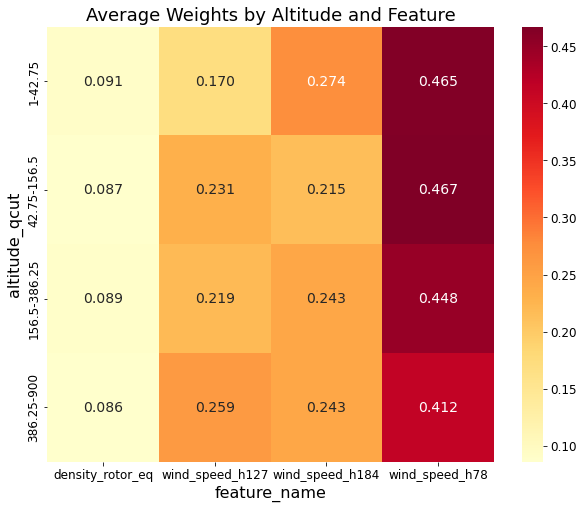

In [ ]:
pivot_df = merge_altitude.pivot_table(
    values='avg_weight',
    index='altitude_qcut',
    columns='feature_name',
    aggfunc='mean'
)
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('Average Weights by Altitude and Feature')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
merge_altitude.boxplot(column='avg_weight', by='altitude_qcut', ax=ax)
plt.suptitle('Distribution of avg_weight by Altitude')
plt.xlabel('Altitude Group')
plt.ylabel('Average Weight')
plt.show()

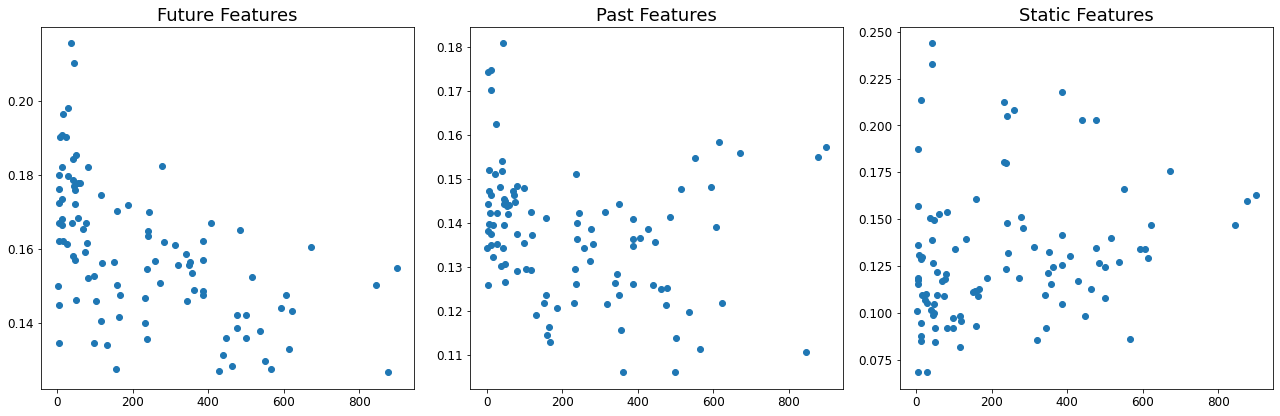

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ['Future Features', 'Past Features', 'Static Features']
plots = [future, past, static]
for ax, title, plot in zip(axes, titles, plots):
    ax.set_title(title)
    x = plot['altitude']
    y = plot['avg_weight']
    ax.scatter(x, y) # Placeholder for scatterplot logic

plt.tight_layout()
plt.show()

In [5]:
def merge_importance(params: pd.DataFrame, importances: pd.DataFrame, static: bool = False) -> pd.DataFrame:
    df_params = params.copy()
    df_importances = importances.copy()
    df_past = df_importances[df_importances['feature_type'] == 'past'].copy()
    idx_max_past = df_past.groupby('station_id')['avg_weight'].idxmax()
    df_most_important_past = df_past.loc[idx_max_past, ['station_id', 'feature_name', 'avg_weight']]
    df_most_important_past = df_most_important_past.rename(columns={
        'feature_name': 'most_important_past_feature',
        'avg_weight': 'most_important_past_weight'
    })
    if static:
        df_static = importances[importances['feature_type'] == 'static'].copy()
        idx_max_static = df_static.groupby('station_id')['avg_weight'].idxmax()
        df_most_important_static = df_static.loc[idx_max_static, ['station_id', 'feature_name', 'avg_weight']]
        df_most_important_static = df_most_important_static.rename(columns={
            'feature_name': 'most_important_static_feature',
            'avg_weight': 'most_important_static_weight'
        })
        params_importance = df_params.merge(df_most_important_static, on='station_id', how='left')
    else:
        params_importance = df_params.copy()
    # Filter for future features and find the most important one per station
    df_future = importances[importances['feature_type'] == 'future'].copy()
    idx_max_future = df_future.groupby('station_id')['avg_weight'].idxmax()
    df_most_important_future = df_future.loc[idx_max_future, ['station_id', 'feature_name', 'avg_weight']]
    df_most_important_future = df_most_important_future.rename(columns={
        'feature_name': 'most_important_future_feature',
        'avg_weight': 'most_important_future_weight'
    })
    # Merge with df_params
    params_importance = params_importance.merge(df_most_important_past, on='station_id', how='left')
    params_importance = params_importance.merge(df_most_important_future, on='station_id', how='left')
    return params_importance

In [6]:
df_global_importance = merge_importance(df_params, df_all, static=False)

in_sample = [True if park in parks_50 else False for park in df_global_importance['station_id']]

df_nostatic_importance = merge_importance(df_params, df_nostatic, static=False)
df_nostatic_importance['in_sample'] = in_sample

df_wind50_importance = merge_importance(df_params, df_wind50, static=True)
df_wind50_importance['in_sample'] = in_sample

df_wind100_importance = merge_importance(df_params, df_wind100, static=True)
df_wind100_importance['in_sample'] = in_sample

## 2. Get Test Results

In [7]:
df_test_all = pd.read_csv('../data/test_results/test_results_all.csv', dtype={'station_id': str})

df_test_nostatic = pd.read_csv('../data/test_results/test_results_wind_50_nostatic.csv', dtype={'station_id': str})

df_test_50 = pd.read_csv('../data/test_results/test_results_wind_50.csv', dtype={'station_id': str})

df_test_100 = pd.read_csv('../data/test_results/test_results_wind_100.csv', dtype={'station_id': str})

In [8]:
df_compare = pd.merge(df_test_100, df_test_all, on=['station_id'], suffixes=('_100', '_all'))
df_compare = pd.merge(df_compare, df_test_50, on=['station_id'])
df_compare.rename(columns={'r2': 'r2_50', 'rmse': 'rmse_50', 'mae': 'mae_50'}, inplace=True)
df_compare = pd.merge(df_compare, df_test_nostatic, on=['station_id'])
df_compare.rename(columns={'r2': 'r2_nostatic', 'rmse': 'rmse_nostatic', 'mae': 'mae_nostatic'}, inplace=True)

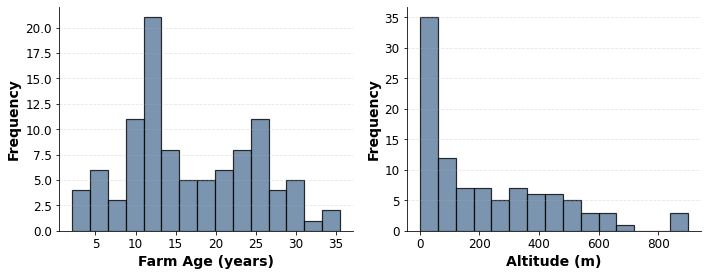

✓ Saved: figs/park_age_altitude_distribution.png


In [8]:
# Output-Verzeichnis erstellen
output_dir = 'figs'
os.makedirs(output_dir, exist_ok=True)

# Paper-ready Settings
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    #'font.family': 'serif',
    #'font.serif': ['Times New Roman', 'DejaVu Serif'],
})

# Zwei Histogramme nebeneinander
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Neutrale Farbe
neutral_color = '#5A7A9B'  # Neutral blau-grau

# 1. PARK AGE DISTRIBUTION
axes[0].hist(df_params['park_age'], bins=15, color=neutral_color, alpha=0.8, edgecolor='black', linewidth=1.2)
axes[0].set_xlabel('Farm Age (years)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=14, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# 2. ALTITUDE DISTRIBUTION
axes[1].hist(df_params['altitude'], bins=15, color=neutral_color, alpha=0.8, edgecolor='black', linewidth=1.2)
axes[1].set_xlabel('Altitude (m)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=14, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(f'{output_dir}/park_age_altitude_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {output_dir}/park_age_altitude_distribution.png")

In [9]:
df_params.turbine_type.value_counts()

turbine_type
Enercon E-115 2.500      21
Vestas V80-1.8           19
Vestas V90               18
Enercon E-70 E4 2.300    16
Vestas V112-3.45         13
Enercon E-82 E2 2.000    13
Name: count, dtype: int64

In [11]:
df_nostatic_importance.to_csv('df_nostatic_importance.csv', index=False)
df_wind50_importance.to_csv('df_wind50_importance.csv', index=False)
df_wind100_importance.to_csv('df_wind100_importance.csv', index=False)

#df_compare.to_csv('../data/test_results/df_compare.csv', index=False)

## 3. Scatterplot of Results

/tmp/ipykernel_1587873/518124334.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


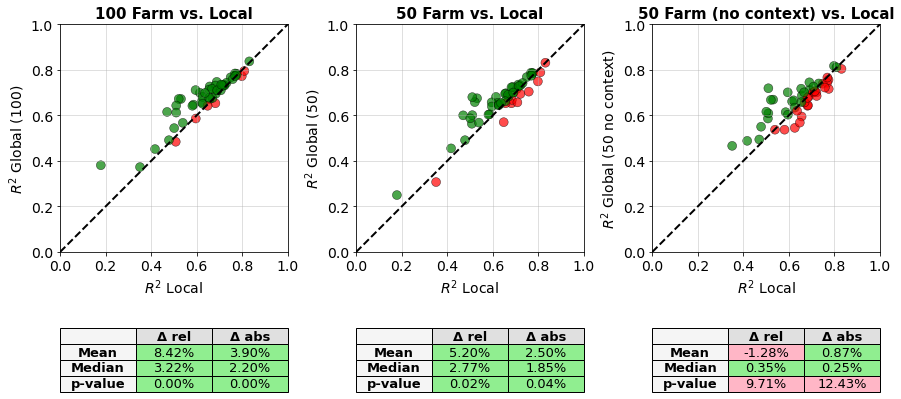

In [9]:
# Daten laden mit Semikolon als Trennzeichen
df = pd.read_csv('../data/test_results/test_performance.csv', sep=';')

# Prozent-Strings in numerische Werte konvertieren
def convert_percent(value):
    if isinstance(value, str) and '%' in value:
        return float(value.replace('%', '')) / 100
    return value

# R²-Spalten konvertieren
for col in ['r2_100', 'r2_all', 'r2_50', 'r2_nostatic']:
    df[col] = df[col].apply(convert_percent)

# Figure mit Grid erstellen (2 Zeilen: obere für Plots, untere für Tabellen)
fig = plt.figure(figsize=(20, 7))
gs = fig.add_gridspec(2, 4, height_ratios=[4, 1], hspace=0.4, wspace=0.3)

# Plot-Konfigurationen
plot_configs = [
    {
        'x': 'r2_all',
        'y': 'r2_100',
        'xlabel': '$R^2$ Local',
        'ylabel': '$R^2$ Global (100)',
        'title': '100 Farm vs. Local',
        'filter_insample': True  # 100 Park: kein Filter
    },
    {
        'x': 'r2_all',
        'y': 'r2_50',
        'xlabel': '$R^2$ Local',
        'ylabel': '$R^2$ Global (50)',
        'title': '50 Farm vs. Local',
        'filter_insample': True  # 50 Park: Filter auf in_sample = True
    },
    {
        'x': 'r2_all',
        'y': 'r2_nostatic',
        'xlabel': '$R^2$ Local',
        'ylabel': '$R^2$ Global (50 no context)',
        'title': '50 Farm (no context) vs. Local',
        'filter_insample': True  # 50 Park Nostatic: Filter auf in_sample = True
    },
    # {
    #     'x': 'r2_nostatic',
    #     'y': 'r2_50',
    #     'xlabel': '$R^2$ Global (50 no context)',
    #     'ylabel': '$R^2$ Global (50)',
    #     'title': '50 Park vs. 50 Park (no context)',
    #     'filter_insample': True  # 50 Park vs 50 Park: Filter auf in_sample = True
    # }
]

# Jeden Plot erstellen
for idx, config in enumerate(plot_configs):
    # Subplot für Scatterplot
    ax = fig.add_subplot(gs[0, idx])

    # DataFrame filtern falls benötigt
    if config['filter_insample']:
        df_plot = df[df['in_sample'] == True].copy()
    else:
        df_plot = df.copy()

    # Nur Zeilen verwenden, wo beide Werte vorhanden sind
    valid_mask = df_plot[config['x']].notna() & df_plot[config['y']].notna()
    x_data = df_plot.loc[valid_mask, config['x']]
    y_data = df_plot.loc[valid_mask, config['y']]

    # Differenzen berechnen
    delta_abs = y_data - x_data
    delta_rel = y_data / x_data - 1
    # drop outliers
    if idx == 3:
        delta_rel = delta_rel[delta_rel > -1]
    _, p_value_abs = wilcoxon(delta_abs, alternative='greater')
    _, p_value_rel = wilcoxon(delta_rel, alternative='greater')

    # Farben bestimmen: grün wenn oberhalb der Diagonalen, rot wenn unterhalb
    colors = ['green' if y > x else 'red' for x, y in zip(x_data, y_data)]

    # Scatterplot
    ax.scatter(x_data, y_data, c=colors, alpha=0.7, edgecolors='black', linewidth=0.5, s=80)

    # Diagonale zeichnen (von 0 bis 1)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Diagonal')

    # Achsenbeschriftungen und Titel
    ax.set_xlabel(config['xlabel'], fontsize=14)
    ax.set_ylabel(config['ylabel'], fontsize=14)
    ax.set_title(config['title'], fontsize=15, fontweight='bold')

    # Wertebereich auf 0 bis 1 setzen
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.tick_params(labelsize=14)

    # Grid
    ax.grid(True, alpha=0.5)

    # Gleiche Skalierung für beide Achsen
    ax.set_aspect('equal', adjustable='box')

    # Tabelle unter dem Plot
    # Tabelle unter dem Plot
    ax_table = fig.add_subplot(gs[1, idx])
    ax_table.axis('off')

    # Statistiken berechnen
    mean_rel = delta_rel.mean()
    median_rel = delta_rel.median()
    mean_abs = delta_abs.mean()
    median_abs = delta_abs.median()

    stats_data = [
        ['', 'Δ rel', 'Δ abs'],
        ['Mean', f'{mean_rel:.2%}', f'{mean_abs:.2%}'],
        ['Median', f'{median_rel:.2%}', f'{median_abs:.2%}'],
        ['p-value', f'{p_value_rel:.2%}', f'{p_value_abs:.2%}']
    ]

    # Tabelle erstellen
    table = ax_table.table(cellText=stats_data,
                           loc='center',
                           cellLoc='center',
                           bbox=[0, 0, 1, 1])

    table.auto_set_font_size(False)
    table.set_fontsize(13)
    table.scale(1, 2)

    # Header-Zeile und erste Spalte hervorheben
    for i in range(3):
        table[(0, i)].set_facecolor('#E0E0E0')
        table[(0, i)].set_text_props(weight='bold')
    for i in range(4):
        table[(i, 0)].set_facecolor('#F5F5F5')
        table[(i, 0)].set_text_props(weight='bold')

    # Datenzellen einfärben basierend auf Werten
    # Zeile 1 (Mittelwert): Spalte 1 = Δ rel, Spalte 2 = Δ abs
    table[(1, 1)].set_facecolor('#90EE90' if mean_rel > 0 else '#FFB6C6')  # lightgreen / lightred
    table[(1, 2)].set_facecolor('#90EE90' if mean_abs > 0 else '#FFB6C6')

    # Zeile 2 (Median): Spalte 1 = Δ rel, Spalte 2 = Δ abs
    table[(2, 1)].set_facecolor('#90EE90' if median_rel > 0 else '#FFB6C6')
    table[(2, 2)].set_facecolor('#90EE90' if median_abs > 0 else '#FFB6C6')

    table[(3, 1)].set_facecolor('#90EE90' if p_value_rel < 0.05 else '#FFB6C6')  # Gelb wenn signifikant
    table[(3, 2)].set_facecolor('#90EE90' if p_value_abs < 0.05 else '#FFB6C6')

plt.tight_layout()
plt.savefig('figs/r2_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

/tmp/ipykernel_347573/2889186766.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


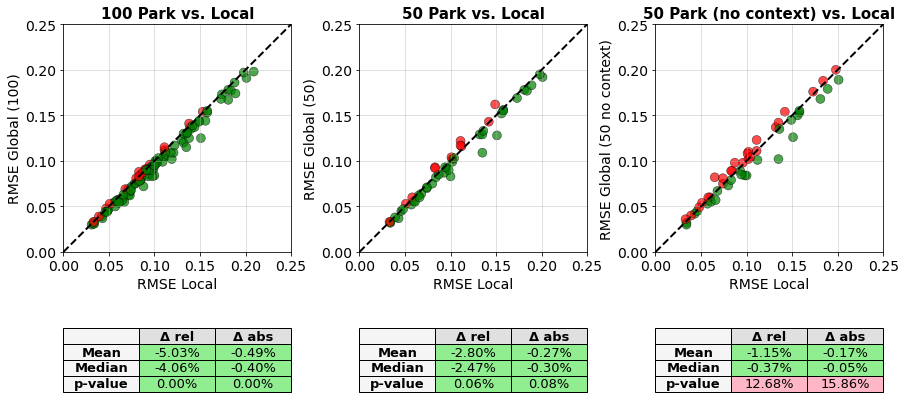

In [25]:
# Prozent-Strings in numerische Werte konvertieren
def convert_percent(value):
    if isinstance(value, str) and '%' in value:
        return float(value.replace('%', '')) / 100
    return value

# R²-Spalten konvertieren
for col in ['rmse_100', 'rmse_all', 'rmse_50', 'rmse_nostatic']:
    df[col] = df[col].apply(convert_percent)

# Figure mit Grid erstellen (2 Zeilen: obere für Plots, untere für Tabellen)
fig = plt.figure(figsize=(20, 7))
gs = fig.add_gridspec(2, 4, height_ratios=[4, 1], hspace=0.4, wspace=0.3)

# Plot-Konfigurationen
plot_configs = [
    {
        'x': 'rmse_all',
        'y': 'rmse_100',
        'xlabel': 'RMSE Local',
        'ylabel': 'RMSE Global (100)',
        'title': '100 Park vs. Local',
        'filter_insample': False  # 100 Park: kein Filter
    },
    {
        'x': 'rmse_all',
        'y': 'rmse_50',
        'xlabel': 'RMSE Local',
        'ylabel': 'RMSE Global (50)',
        'title': '50 Park vs. Local',
        'filter_insample': True  # 50 Park: Filter auf in_sample = True
    },
    {
        'x': 'rmse_all',
        'y': 'rmse_nostatic',
        'xlabel': 'RMSE Local',
        'ylabel': 'RMSE Global (50 no context)',
        'title': '50 Park (no context) vs. Local',
        'filter_insample': True  # 50 Park Nostatic: Filter auf in_sample = True
    },
    # {
    #     'x': 'rmse_nostatic',
    #     'y': 'rmse_50',
    #     'xlabel': 'RMSE Global (50 no context)',
    #     'ylabel': 'RMSE Global (50)',
    #     'title': '50 Park vs. 50 Park (no context)',
    #     'filter_insample': True  # 50 Park vs 50 Park: Filter auf in_sample = True
    # }
]

# Jeden Plot erstellen
for idx, config in enumerate(plot_configs):
    # Subplot für Scatterplot
    ax = fig.add_subplot(gs[0, idx])

    # DataFrame filtern falls benötigt
    if config['filter_insample']:
        df_plot = df[df['in_sample'] == True].copy()
    else:
        df_plot = df.copy()

    # Nur Zeilen verwenden, wo beide Werte vorhanden sind
    valid_mask = df_plot[config['x']].notna() & df_plot[config['y']].notna()
    x_data = df_plot.loc[valid_mask, config['x']]
    y_data = df_plot.loc[valid_mask, config['y']]

    # Differenzen berechnen
    delta_abs = y_data - x_data
    delta_rel = y_data / x_data - 1
    # drop outliers
    #if idx == 3:
    #    delta_rel = delta_rel[delta_rel > -1]
    _, p_value_abs = wilcoxon((x_data - y_data), alternative='greater')
    _, p_value_rel = wilcoxon((x_data / y_data - 1), alternative='greater')

    # Farben bestimmen: grün wenn oberhalb der Diagonalen, rot wenn unterhalb
    colors = ['green' if y < x else 'red' for x, y in zip(x_data, y_data)]

    # Scatterplot
    ax.scatter(x_data, y_data, c=colors, alpha=0.7, edgecolors='black', linewidth=0.5, s=80)

    # Diagonale zeichnen (von 0 bis 1)
    ax.plot([0, 0.25], [0, 0.25], 'k--', linewidth=2, label='Diagonal')

    # Achsenbeschriftungen und Titel
    ax.set_xlabel(config['xlabel'], fontsize=14)
    ax.set_ylabel(config['ylabel'], fontsize=14)
    ax.set_title(config['title'], fontsize=15, fontweight='bold')

    # Wertebereich auf 0 bis 1 setzen
    ax.set_xlim(0, 0.25)
    ax.set_ylim(0, 0.25)

    ax.tick_params(labelsize=14)

    # Grid
    ax.grid(True, alpha=0.5)

    # Gleiche Skalierung für beide Achsen
    ax.set_aspect('equal', adjustable='box')

    # Tabelle unter dem Plot
    # Tabelle unter dem Plot
    ax_table = fig.add_subplot(gs[1, idx])
    ax_table.axis('off')

    # Statistiken berechnen
    mean_rel = delta_rel.mean()
    median_rel = delta_rel.median()
    mean_abs = delta_abs.mean()
    median_abs = delta_abs.median()

    stats_data = [
        ['', 'Δ rel', 'Δ abs'],
        ['Mean', f'{mean_rel:.2%}', f'{mean_abs:.2%}'],
        ['Median', f'{median_rel:.2%}', f'{median_abs:.2%}'],
        ['p-value', f'{p_value_rel:.2%}', f'{p_value_abs:.2%}']
    ]

    # Tabelle erstellen
    table = ax_table.table(cellText=stats_data,
                           loc='center',
                           cellLoc='center',
                           bbox=[0, 0, 1, 1])

    table.auto_set_font_size(False)
    table.set_fontsize(13)
    table.scale(1, 2)

    # Header-Zeile und erste Spalte hervorheben
    for i in range(3):
        table[(0, i)].set_facecolor('#E0E0E0')
        table[(0, i)].set_text_props(weight='bold')
    for i in range(4):
        table[(i, 0)].set_facecolor('#F5F5F5')
        table[(i, 0)].set_text_props(weight='bold')

    # Datenzellen einfärben basierend auf Werten
    # Zeile 1 (Mittelwert): Spalte 1 = Δ rel, Spalte 2 = Δ abs
    table[(1, 1)].set_facecolor('#90EE90' if mean_rel < 0 else '#FFB6C6')  # lightgreen / lightred
    table[(1, 2)].set_facecolor('#90EE90' if mean_abs < 0 else '#FFB6C6')

    # Zeile 2 (Median): Spalte 1 = Δ rel, Spalte 2 = Δ abs
    table[(2, 1)].set_facecolor('#90EE90' if median_rel < 0 else '#FFB6C6')
    table[(2, 2)].set_facecolor('#90EE90' if median_abs < 0 else '#FFB6C6')

    table[(3, 1)].set_facecolor('#90EE90' if p_value_rel < 0.05 else '#FFB6C6')  # Gelb wenn signifikant
    table[(3, 2)].set_facecolor('#90EE90' if p_value_abs < 0.05 else '#FFB6C6')

plt.tight_layout()
plt.savefig('figs/rmse_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

/tmp/ipykernel_347573/3803532826.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


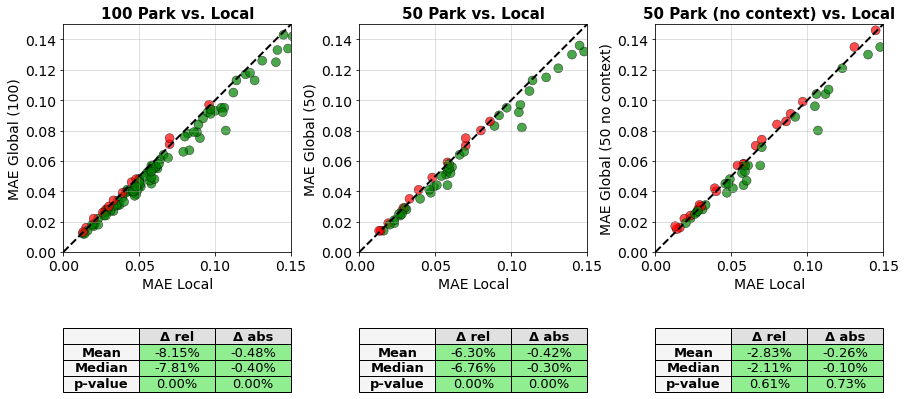

In [27]:
# Prozent-Strings in numerische Werte konvertieren
def convert_percent(value):
    if isinstance(value, str) and '%' in value:
        return float(value.replace('%', '')) / 100
    return value

# R²-Spalten konvertieren
for col in ['mae_100', 'mae_all', 'mae_50', 'mae_nostatic']:
    df[col] = df[col].apply(convert_percent)

# Figure mit Grid erstellen (2 Zeilen: obere für Plots, untere für Tabellen)
fig = plt.figure(figsize=(20, 7))
gs = fig.add_gridspec(2, 4, height_ratios=[4, 1], hspace=0.4, wspace=0.3)

# Plot-Konfigurationen
plot_configs = [
    {
        'x': 'mae_all',
        'y': 'mae_100',
        'xlabel': 'MAE Local',
        'ylabel': 'MAE Global (100)',
        'title': '100 Park vs. Local',
        'filter_insample': False  # 100 Park: kein Filter
    },
    {
        'x': 'mae_all',
        'y': 'mae_50',
        'xlabel': 'MAE Local',
        'ylabel': 'MAE Global (50)',
        'title': '50 Park vs. Local',
        'filter_insample': True  # 50 Park: Filter auf in_sample = True
    },
    {
        'x': 'mae_all',
        'y': 'mae_nostatic',
        'xlabel': 'MAE Local',
        'ylabel': 'MAE Global (50 no context)',
        'title': '50 Park (no context) vs. Local',
        'filter_insample': True  # 50 Park Nostatic: Filter auf in_sample = True
    },
    # {
    #     'x': 'mae_nostatic',
    #     'y': 'mae_50',
    #     'xlabel': 'MAE Global (50 no context)',
    #     'ylabel': 'MAE Global (50)',
    #     'title': '50 Park vs. 50 Park (no context)',
    #     'filter_insample': True  # 50 Park vs 50 Park: Filter auf in_sample = True
    # }
]

# Jeden Plot erstellen
for idx, config in enumerate(plot_configs):
    # Subplot für Scatterplot
    ax = fig.add_subplot(gs[0, idx])

    # DataFrame filtern falls benötigt
    if config['filter_insample']:
        df_plot = df[df['in_sample'] == True].copy()
    else:
        df_plot = df.copy()

    # Nur Zeilen verwenden, wo beide Werte vorhanden sind
    valid_mask = df_plot[config['x']].notna() & df_plot[config['y']].notna()
    x_data = df_plot.loc[valid_mask, config['x']]
    y_data = df_plot.loc[valid_mask, config['y']]

    # Differenzen berechnen
    delta_abs = y_data - x_data
    delta_rel = y_data / x_data - 1
    # drop outliers
    #if idx == 3:
    #    delta_rel = delta_rel[delta_rel > -1]
    _, p_value_abs = wilcoxon((x_data - y_data), alternative='greater')
    _, p_value_rel = wilcoxon((x_data / y_data - 1), alternative='greater')

    # Farben bestimmen: grün wenn oberhalb der Diagonalen, rot wenn unterhalb
    colors = ['green' if y < x else 'red' for x, y in zip(x_data, y_data)]

    # Scatterplot
    ax.scatter(x_data, y_data, c=colors, alpha=0.7, edgecolors='black', linewidth=0.5, s=80)

    # Diagonale zeichnen (von 0 bis 1)
    ax.plot([0, 0.15], [0, 0.15], 'k--', linewidth=2, label='Diagonal')

    # Achsenbeschriftungen und Titel
    ax.set_xlabel(config['xlabel'], fontsize=14)
    ax.set_ylabel(config['ylabel'], fontsize=14)
    ax.set_title(config['title'], fontsize=15, fontweight='bold')

    # Wertebereich auf 0 bis 1 setzen
    ax.set_xlim(0, 0.15)
    ax.set_ylim(0, 0.15)

    ax.tick_params(labelsize=14)

    # Grid
    ax.grid(True, alpha=0.5)

    # Gleiche Skalierung für beide Achsen
    ax.set_aspect('equal', adjustable='box')

    # Tabelle unter dem Plot
    # Tabelle unter dem Plot
    ax_table = fig.add_subplot(gs[1, idx])
    ax_table.axis('off')

    # Statistiken berechnen
    mean_rel = delta_rel.mean()
    median_rel = delta_rel.median()
    mean_abs = delta_abs.mean()
    median_abs = delta_abs.median()

    stats_data = [
        ['', 'Δ rel', 'Δ abs'],
        ['Mean', f'{mean_rel:.2%}', f'{mean_abs:.2%}'],
        ['Median', f'{median_rel:.2%}', f'{median_abs:.2%}'],
        ['p-value', f'{p_value_rel:.2%}', f'{p_value_abs:.2%}']
    ]

    # Tabelle erstellen
    table = ax_table.table(cellText=stats_data,
                           loc='center',
                           cellLoc='center',
                           bbox=[0, 0, 1, 1])

    table.auto_set_font_size(False)
    table.set_fontsize(13)
    table.scale(1, 2)

    # Header-Zeile und erste Spalte hervorheben
    for i in range(3):
        table[(0, i)].set_facecolor('#E0E0E0')
        table[(0, i)].set_text_props(weight='bold')
    for i in range(4):
        table[(i, 0)].set_facecolor('#F5F5F5')
        table[(i, 0)].set_text_props(weight='bold')

    # Datenzellen einfärben basierend auf Werten
    # Zeile 1 (Mittelwert): Spalte 1 = Δ rel, Spalte 2 = Δ abs
    table[(1, 1)].set_facecolor('#90EE90' if mean_rel < 0 else '#FFB6C6')  # lightgreen / lightred
    table[(1, 2)].set_facecolor('#90EE90' if mean_abs < 0 else '#FFB6C6')

    # Zeile 2 (Median): Spalte 1 = Δ rel, Spalte 2 = Δ abs
    table[(2, 1)].set_facecolor('#90EE90' if median_rel < 0 else '#FFB6C6')
    table[(2, 2)].set_facecolor('#90EE90' if median_abs < 0 else '#FFB6C6')

    table[(3, 1)].set_facecolor('#90EE90' if p_value_rel < 0.05 else '#FFB6C6')  # Gelb wenn signifikant
    table[(3, 2)].set_facecolor('#90EE90' if p_value_abs < 0.05 else '#FFB6C6')

plt.tight_layout()
plt.savefig('figs/mae_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

## 4. Feature Importance Analysis Local Models

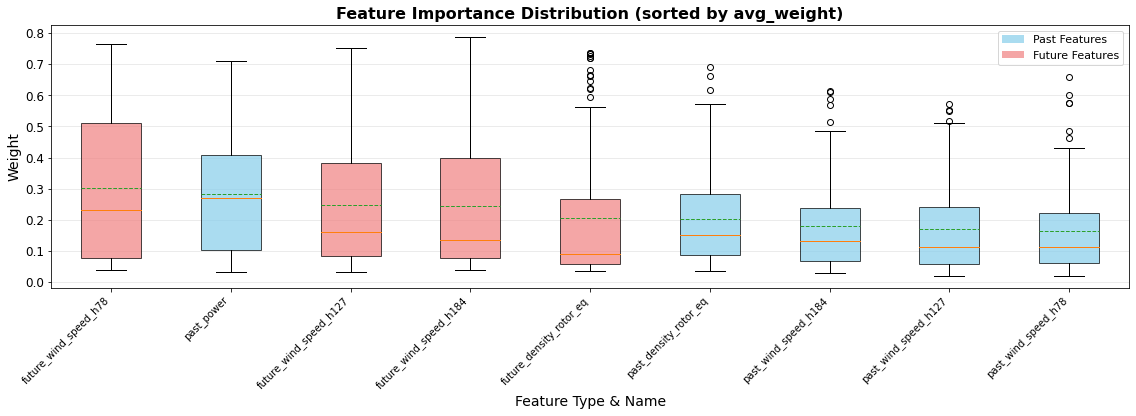

In [10]:
# Feature-Label erstellen (feature_type + feature_name)
df_all['feature_label'] = df_all['feature_type'] + '_' + df_all['feature_name']

# Nach avg_weight gruppieren und sortieren
feature_order = df_all.groupby('feature_label')['avg_weight'].mean().sort_values(ascending=False).index.tolist()

# Daten für Boxplots vorbereiten
boxplot_data = []
labels = []
colors = []

for feature in feature_order:
    feature_df = df_all[df_all['feature_label'] == feature]
    boxplot_data.append(feature_df['avg_weight'].values)
    labels.append(feature)

    # Farbe basierend auf feature_type bestimmen
    feature_type = feature_df['feature_type'].iloc[0]
    if 'past' in feature_type.lower():
        colors.append('skyblue')
    else:  # future features
        colors.append('lightcoral')

# Plot erstellen
fig, ax = plt.subplots(figsize=(16, 6))

# Boxplots
bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True,
                showmeans=True, meanline=True)

# Farben anwenden
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Achsenbeschriftungen
ax.set_ylabel('Weight', fontsize=14)
ax.set_xlabel('Feature Type & Name', fontsize=14)
ax.set_title('Feature Importance Distribution (sorted by avg_weight)', fontsize=16, fontweight='bold')

# X-Achsen-Labels drehen für bessere Lesbarkeit
plt.xticks(rotation=45, ha='right', fontsize=10)
ax.tick_params(axis='y', labelsize=12)

# Grid
ax.grid(True, alpha=0.3, axis='y')

# Legende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='skyblue', alpha=0.7, label='Past Features'),
    Patch(facecolor='lightcoral', alpha=0.7, label='Future Features')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

## 5. Feature Importance Analysis Global Models

In [ ]:
def feature_importance_global(df: pd.DataFrame, model: str):
    # Nach wind_100 filtern
    df_filtered = df_global[df_global['model'] == model].copy()

    # Nach feature_type gruppieren
    static_features = df_filtered[df_filtered['feature_type'] == 'static'].sort_values('avg_weight', ascending=False)
    past_features = df_filtered[df_filtered['feature_type'] == 'past'].sort_values('avg_weight', ascending=False)
    future_features = df_filtered[df_filtered['feature_type'] == 'future'].sort_values('avg_weight', ascending=False)

    # Daten kombinieren
    all_features = pd.concat([static_features, past_features, future_features])
    feature_labels = all_features['feature_name'].tolist()
    weights = all_features['avg_weight'].tolist()

    # Farben definieren (Pastellfarben)
    colors = []
    static_color = '#696969'
    past_color = '#2E7BD4'
    future_color = '#FF8C00'
    colors.extend([static_color] * len(static_features))  # Kräftiges Grau für static
    colors.extend([past_color] * len(past_features))    # Kräftiges Blau für past
    colors.extend([future_color] * len(future_features))  # Kräftiges Orange für future

    # Positionen für vertikale Linien
    line_pos_1 = len(static_features) - 0.5
    line_pos_2 = len(static_features) + len(past_features) - 0.5

    # Plot erstellen
    fig, ax = plt.subplots(figsize=(14, 6))

    # Balkendiagramm
    x_pos = np.arange(len(feature_labels))
    bars = ax.bar(x_pos, weights, color=colors, alpha=0.8, edgecolor='black', linewidth=0.1)

    # Vertikale Trennlinien zwischen Gruppen
    if len(static_features) > 0 and len(past_features) > 0:
        ax.axvline(x=line_pos_1, color='black', linewidth=2, linestyle='-')
    if len(past_features) > 0 and len(future_features) > 0:
        ax.axvline(x=line_pos_2, color='black', linewidth=2, linestyle='-')

    # Achsenbeschriftungen
    ax.set_ylabel('Weight', fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature Name', fontsize=14, fontweight='bold')
    #ax.set_title('Feature Weights for wind_100 Model', fontsize=16, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(feature_labels, rotation=45, ha='right', fontsize=10)
    ax.tick_params(axis='y', labelsize=12)

    # Grid
    ax.grid(True, alpha=0.3, axis='y')

    # Legende
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=static_color, alpha=0.8, edgecolor='black', label='Static Features'),
        Patch(facecolor=past_color, alpha=0.8, edgecolor='black', label='Past Features'),
        Patch(facecolor=future_color, alpha=0.8, edgecolor='black', label='Future Features')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    plt.savefig(f'figs/feature_importance_{model}.png', dpi=600, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

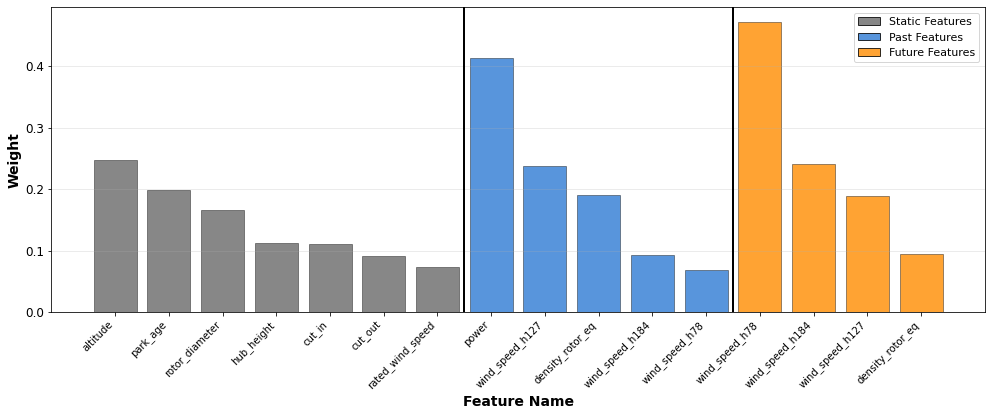

In [10]:
feature_importance_global(df=df_global, model='wind_100')

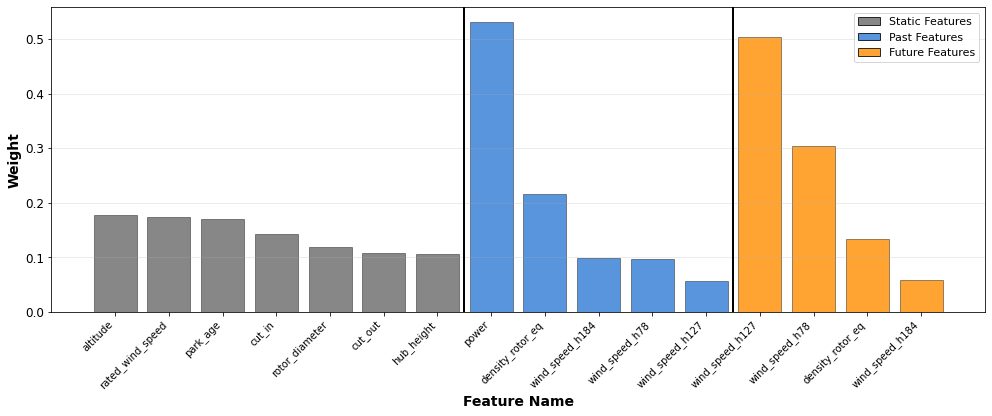

In [11]:
feature_importance_global(df=df_global, model='wind_50')

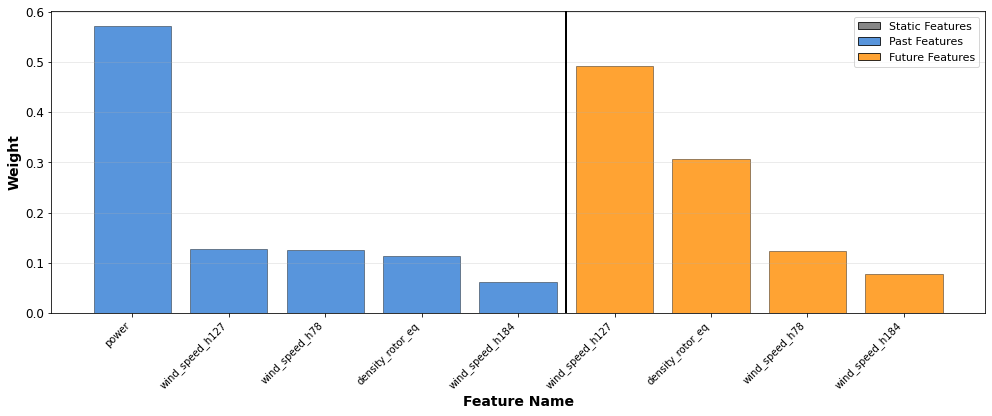

In [12]:
feature_importance_global(df=df_global, model='wind_50_nostatic')